<a href="https://colab.research.google.com/github/dishankjain17/code-for-u/blob/master/voronoitreemap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

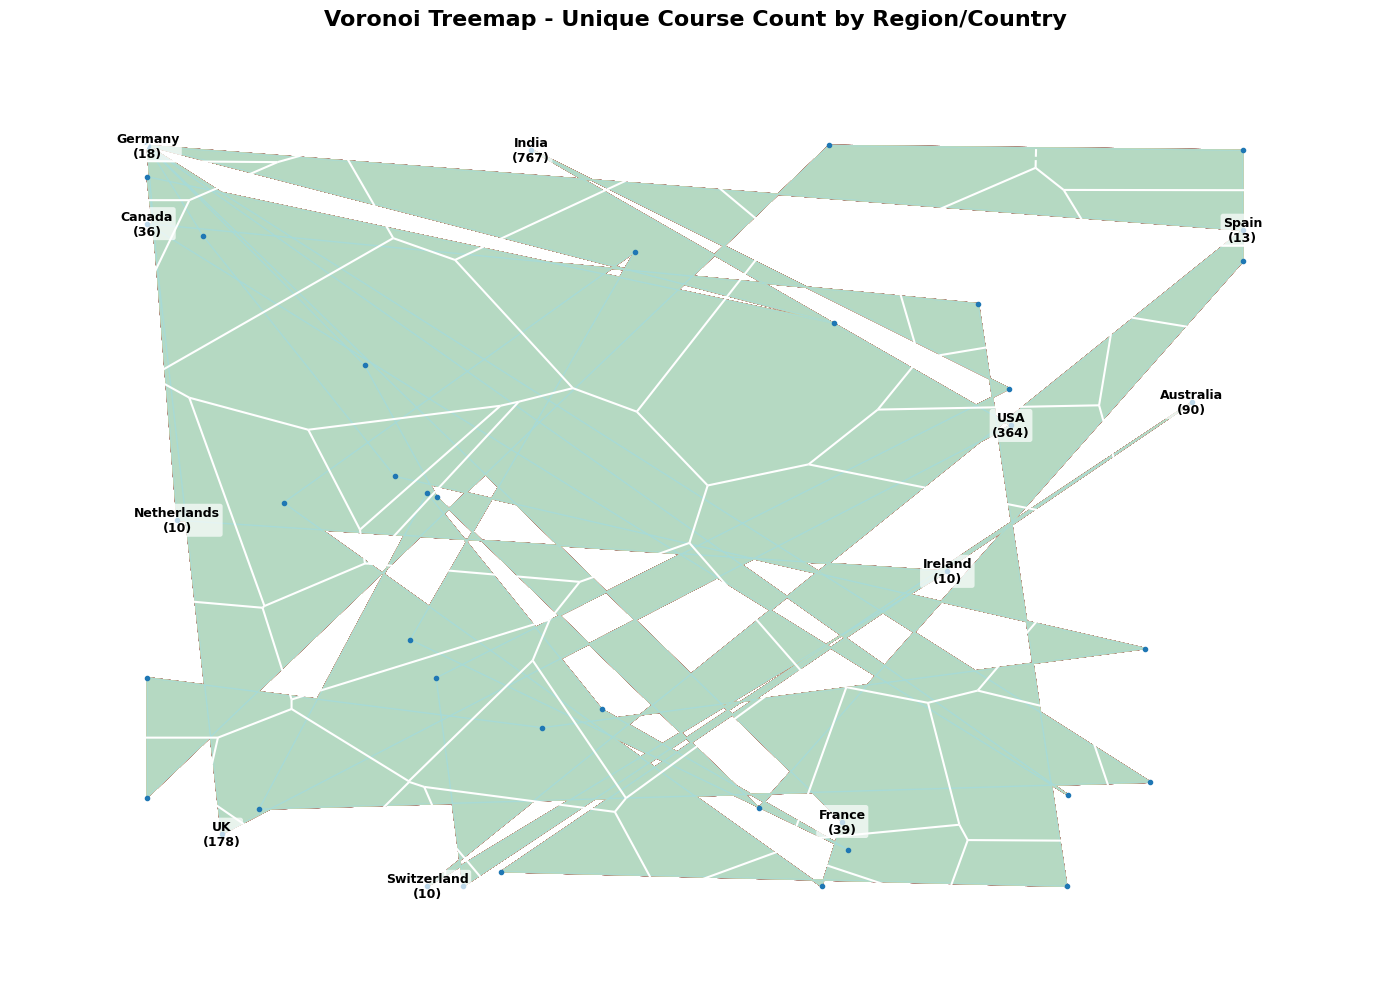

In [ ]:
!pip install scipy matplotlib pandas numpy adjustText

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
from scipy.optimize import minimize
import matplotlib.patches as patches

# 1. Prepare Data
data = {
    "Region": [
        "India", "USA", "UK",
        "Asia", "Asia", "Asia", "Asia", "Asia", "Asia", "Asia", "Asia", "Asia", "Asia", "Asia", "Asia",
        "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe", "Europe",
        "North America", "North America",
        "South America", "South America",
        "Oceania", "Oceania", "Oceania",
        "Africa"
    ],
    "Country": [
        "India", "USA", "UK",
        "UAE", "Thailand", "Saudi Arabia", "Malaysia", "Hong Kong", "Singapore", "Oman", "Qatar", "Philippines", "Israel", "Turkey", "China",
        "France", "Germany", "Spain", "Switzerland", "Ireland", "Netherlands", "Italy", "Lithuania", "Portugal", "Russia", "Sweden", "Hungary", "Norway", "Ukraine", "Belgium", "Denmark", "Finland", "Romania", "Poland", "Austria", "Luxembourg",
        "Canada", "Mexico",
        "Colombia", "Brazil",
        "Australia", "New Zealand", "Fiji",
        "South Africa"
    ],
    "Count": [
        767, 364, 178,
        7, 7, 7, 6, 5, 4, 4, 3, 3, 3, 2, 2,
        39, 18, 13, 10, 10, 10, 7, 6, 6, 5, 4, 4, 4, 3, 3, 3, 2, 2, 2, 1, 1,
        36, 3,
        6, 2,
        90, 9, 3,
        5
    ]
}

df = pd.DataFrame(data)

# Group sum for Region-level hierarchy
region_df = df.groupby("Region")["Count"].sum().reset_index()

# 2. Weighted Lloyd's Algorithm Simulation for Treemap Voronoi Layout
def generate_voronoi_treemap(df):
    np.random.seed(42)
    n = len(df)

    # Initialize random points in a unit box
    points = np.random.rand(n, 2)
    weights = df["Count"].values
    weights = weights / weights.sum() # Normalize weights

    # Centroid relaxation towards weight proportions
    for _ in range(50):
        vor = Voronoi(points)
        for i in range(n):
            # Move points proportional to area weights
            points[i] += (np.random.rand(2) - 0.5) * 0.01 * weights[i]
            points[i] = np.clip(points[i], 0.1, 0.9)

    return points

# Compute placement points
points = generate_voronoi_treemap(df)
vor = Voronoi(points)

# 3. Visualization
fig, ax = plt.subplots(figsize=(14, 10))

# Color palette map per Region
unique_regions = df["Region"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_regions)))
region_color_map = dict(zip(unique_regions, colors))

# Plot Voronoi Tesselation
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='white', line_width=1.5, line_style='-')

# Color polygons and add text annotations
for i, point in enumerate(points):
    region = df.iloc[i]["Region"]
    country = df.iloc[i]["Country"]
    count = df.iloc[i]["Count"]

    # Fill polygon color
    ax.fill(vor.points[:, 0], vor.points[:, 1], color=region_color_map[region], alpha=0.6)

    # Labeling larger segments
    if count >= 10:
        ax.text(point[0], point[1], f"{country}\n({count})",
                fontsize=9, weight='bold', ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title("Voronoi Treemap - Unique Course Count by Region/Country", fontsize=16, pad=20, weight='bold')
plt.tight_layout()
plt.show()

In [ ]:
!pip install scipy plotly numpy pandas

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.spatial import SphericalVoronoi

# 1. Prepare Data
data = {
    "Country": [
        "India", "USA", "UK", "Australia", "France",
        "Canada", "Germany", "Spain", "Switzerland", "Ireland"
    ],
    "Count": [767, 364, 178, 90, 39, 36, 18, 13, 10, 10]
}
df = pd.DataFrame(data)

# 2. Generate Points on a Unit Sphere
# Generate N points uniformly distributed on a sphere (Fibonacci lattice approach)
n_points = len(df)
indices = np.arange(0, n_points, dtype=float) + 0.5
phi = np.arccos(1 - 2 * indices / n_points)
theta = np.pi * (1 + 5**0.5) * indices

x = np.cos(theta) * np.sin(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(phi)

centers = np.column_stack((x, y, z))

# 3. Compute Spherical Voronoi Tessellation
radius = 1.0
sv = SphericalVoronoi(centers, radius=radius)
sv.sort_vertices_of_regions()

# 4. Create Interactive 3D Plot using Plotly
fig = go.Figure()

# Plot generator points
fig.add_trace(go.Scatter3d(
    x=centers[:, 0], y=centers[:, 1], z=centers[:, 2],
    mode='markers+text',
    text=df['Country'] + "<br>(" + df['Count'].astype(str) + ")",
    textposition="top center",
    marker=dict(size=6, color='red'),
    name='Country Centers'
))

# Plot Voronoi Cell Polygons on the Sphere Surface
for i, region in enumerate(sv.regions):
    polygon_vertices = sv.vertices[region]

    # Close the loop for visualization
    polygon_vertices = np.vstack([polygon_vertices, polygon_vertices[0]])

    fig.add_trace(go.Scatter3d(
        x=polygon_vertices[:, 0],
        y=polygon_vertices[:, 1],
        z=polygon_vertices[:, 2],
        mode='lines',
        line=dict(color='cyan', width=4),
        showlegend=False
    ))

# 5. Figure Styling
fig.update_layout(
    title="Spherical Voronoi Map Structure",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode='cube'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()